In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import plotnine as p9
import itertools
import numpy as np
import sklearn.linear_model

In [2]:
BYTES_FLOAT = 4 # CONFIRM !!!!! 
BYTES_INDEX = 4 # CONFIRM !!!!!

In [3]:
sliding_windows_df = pd.read_csv('./statistics/sliding_windows.csv')
attention_distillation_df = pd.read_csv('./statistics/attention_distillation.csv')
chefer_importance_df = pd.read_csv('./statistics/chefer_importance.csv')

In [4]:
sliding_windows_df['method'] = 'Sliding Window'
sliding_windows_df['param'] = 'w=' + sliding_windows_df['window_size'].astype(str)
#
attention_distillation_df['method'] = 'Attention Distillation'
attention_distillation_df['param'] = 't=' + attention_distillation_df['threshold'].astype(str)
#
chefer_importance_df['method'] = 'Chefer Importance'
chefer_importance_df['param'] = ('nt=' + chefer_importance_df['node_threshold'].astype(str) + '_et=' + chefer_importance_df['edge_threshold'].astype(str))


In [5]:
common_columns = ['dataset', 'split', 'index','document_length', 'token_count','node_count', 'node_embedding_dimension','edge_count', 'edge_embedding_dimension','method', 'param']
df = pd.concat([sliding_windows_df[common_columns], attention_distillation_df[common_columns], chefer_importance_df[common_columns]], ignore_index = True)

In [6]:
df['node_memory'] = df['node_count'] * df['node_embedding_dimension'] * BYTES_FLOAT
df['edge_feature_memory'] = df['edge_count'] * df['edge_embedding_dimension'] * BYTES_FLOAT
df['edge_index_memory'] = df['edge_count'] * 2 * BYTES_INDEX
df['total_bytes'] = df['node_memory'] + df['edge_feature_memory'] + df['edge_index_memory']
df['total_mega_bytes'] = df['total_bytes'] / (1024**2)
#
df['memory_per_token'] = df['total_bytes'] / df['token_count']
#
df['edge_node_ratio'] = df['edge_count'] / df['node_count']
#
df['graph_density'] = df['edge_count'] / (df['node_count'] ** 2)

# Total Memory vs. Document Length

In [7]:
#### AVERAGE PER DOCUMENT????????? INCLUDE STD BARS?

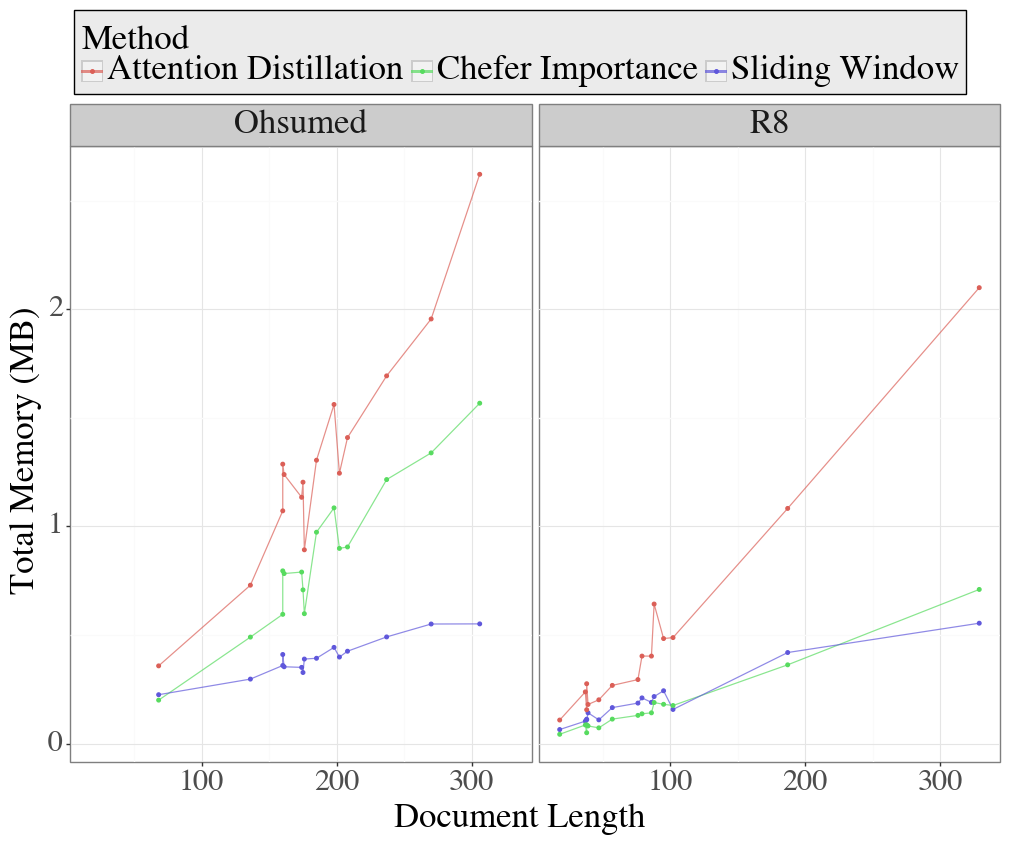

<ggplot: (335430777)>

In [8]:
p9.ggplot(
    df[df['param'].isin(['w=3','t=0.9','nt=0.7_et=0.8'])],
    p9.aes(x = 'document_length', y = 'total_mega_bytes', color = 'method')
  ) + \
    p9.geom_line(alpha = 0.7) + \
    p9.geom_point(size = 1) + \
    p9.xlab('Document Length') + \
    p9.ylab('Total Memory (MB)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

In [9]:
chefer_importance_memory_df = df[df['param'].isin([f'nt={x}_et={y}' for (x, y) in itertools.product([0.5, 0.6, 0.7, 0.8, 0.9, 0.95], repeat = 2)])]
chefer_importance_memory_df[['nt', 'et']] = chefer_importance_memory_df['param'].str.extract(r'nt=(.*)_et=(.*)').astype(float)
chefer_importance_summary_df = chefer_importance_memory_df.groupby(['nt', 'document_length']) \
  .agg(
    mean_mega_bytes = ('total_mega_bytes', 'mean'),
    min_mega_bytes = ('total_mega_bytes', 'min'),
    max_mega_bytes = ('total_mega_bytes', 'max')
  ) \
  .reset_index()

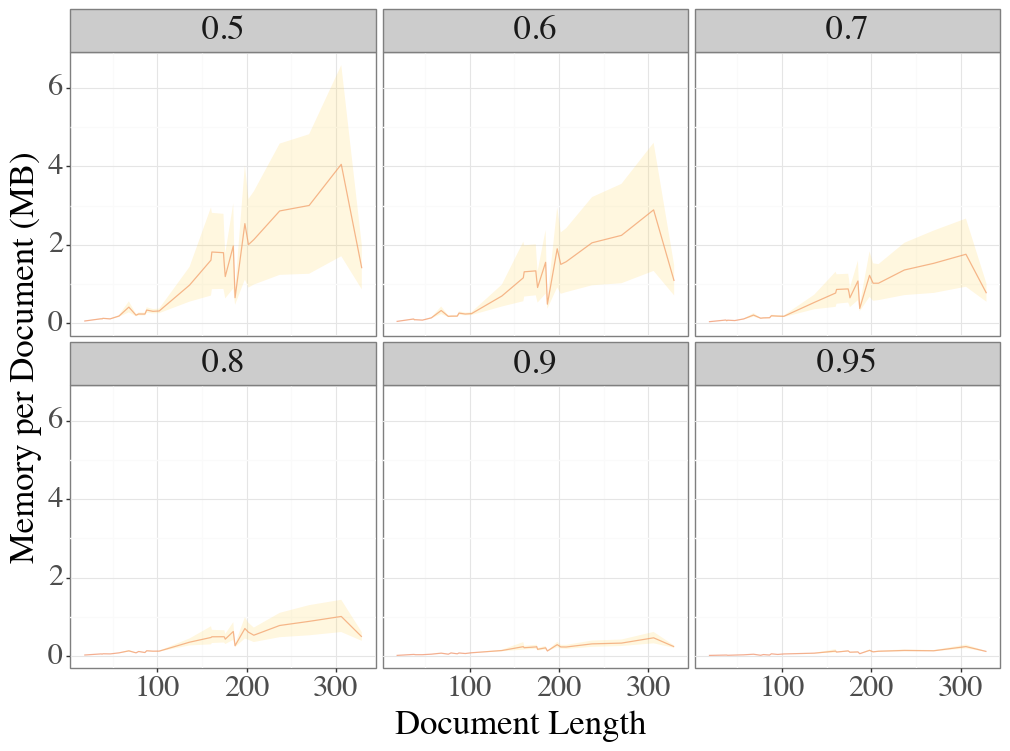

<ggplot: (335606736)>

In [10]:
p9.ggplot(
    chefer_importance_summary_df,
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_mega_bytes'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_mega_bytes', ymax = 'max_mega_bytes'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Document (MB)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

# Memory Per Token vs Document Length

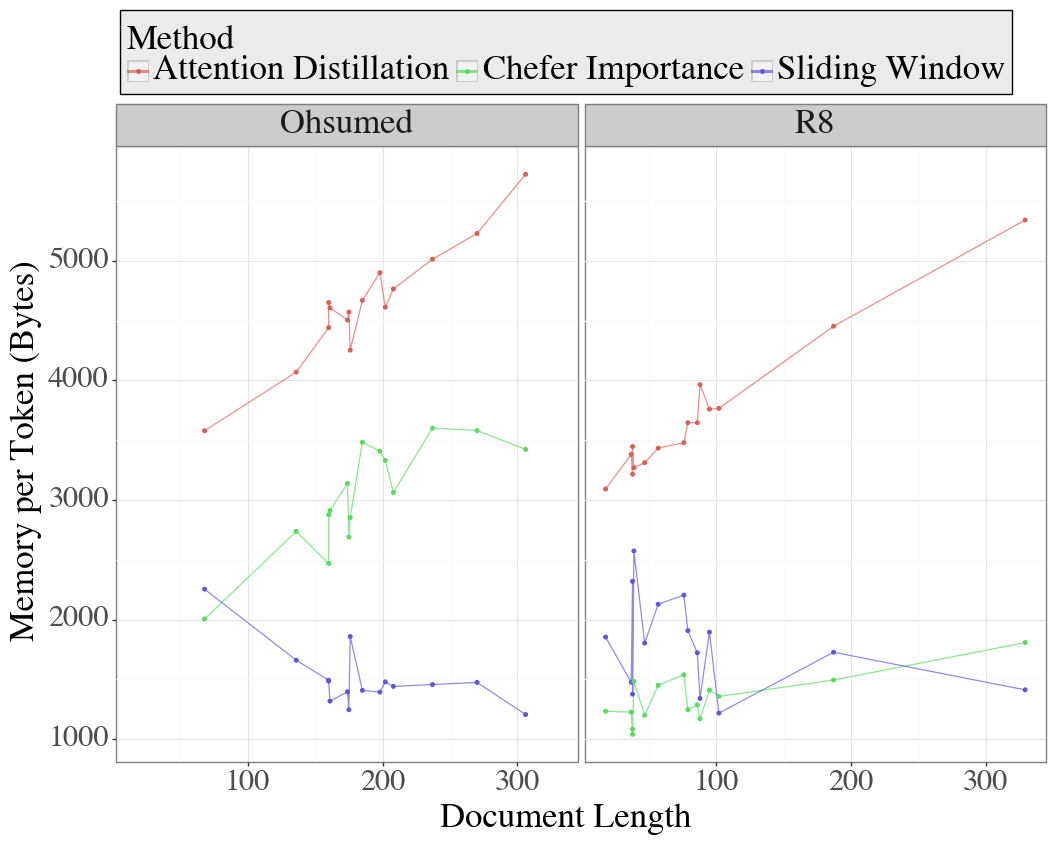

<ggplot: (335799597)>

In [11]:
p9.ggplot(
    df[df['param'].isin(['w=3','t=0.9','nt=0.7_et=0.8'])],
    p9.aes(x = 'document_length', y = 'memory_per_token', color = 'method')
  ) + \
    p9.geom_line(alpha = 0.7) + \
    p9.geom_point(size = 1) + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Token (Bytes)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

In [12]:
chefer_importance_memory_df = df[df['param'].isin([f'nt={x}_et={y}' for (x, y) in itertools.product([0.5, 0.6, 0.7, 0.8, 0.9, 0.95], repeat = 2)])]
chefer_importance_memory_df[['nt', 'et']] = chefer_importance_memory_df['param'].str.extract(r'nt=(.*)_et=(.*)').astype(float)
chefer_importance_summary_df = chefer_importance_memory_df.groupby(['nt', 'document_length']) \
  .agg(
    mean_memory_per_token = ('memory_per_token', 'mean'),
    min_memory_per_token = ('memory_per_token', 'min'),
    max_memory_per_token = ('memory_per_token', 'max')
  ) \
  .reset_index()

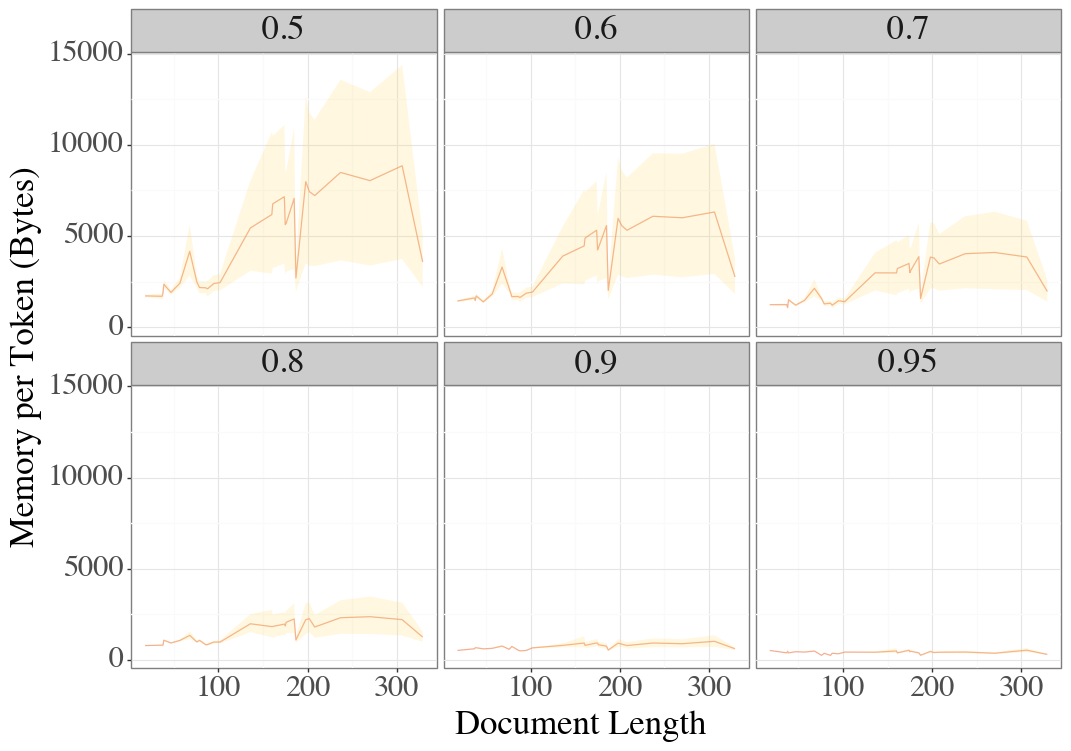

<ggplot: (335888625)>

In [13]:
p9.ggplot(
    chefer_importance_summary_df,
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_memory_per_token'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_memory_per_token', ymax = 'max_memory_per_token'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Token (Bytes)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

# Edge Count vs Document Length (Log–Log)

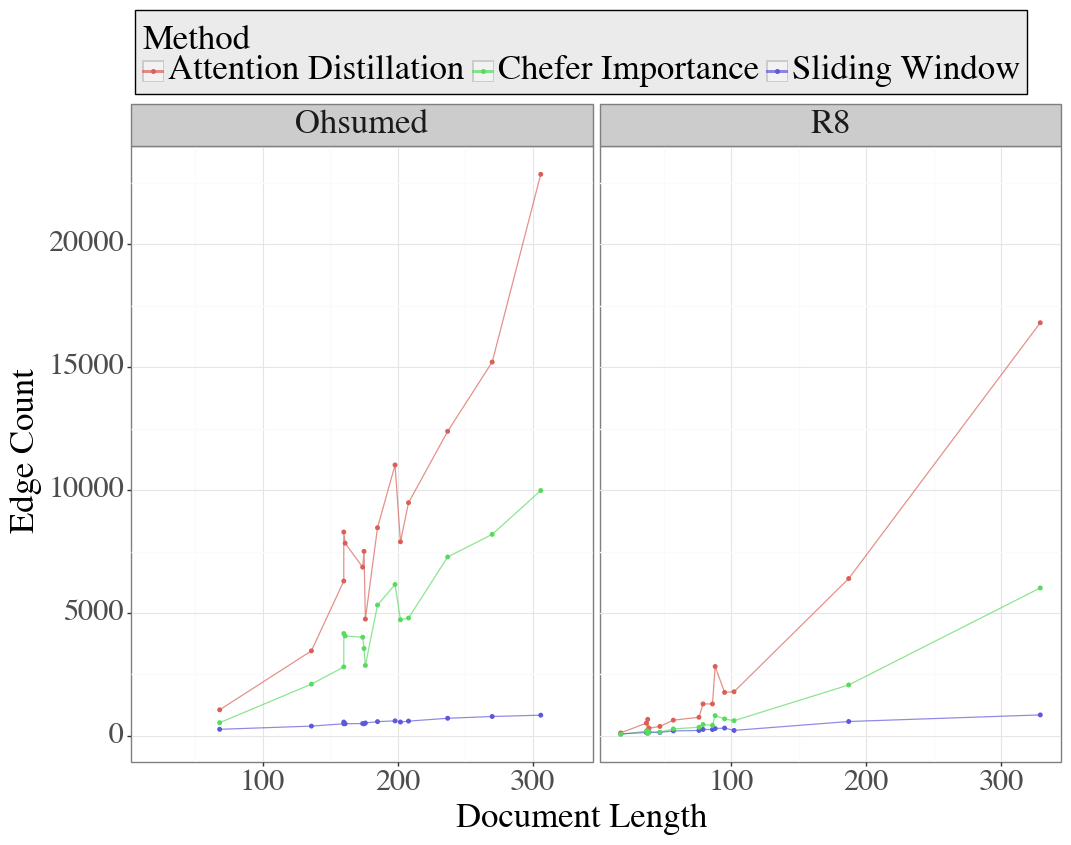

<ggplot: (336040873)>

In [14]:
p9.ggplot(
    df[df['param'].isin(['w=3','t=0.9','nt=0.7_et=0.8'])],
    p9.aes(x = 'document_length', y = 'edge_count', color = 'method')
  ) + \
    p9.geom_line(alpha = 0.7) + \
    p9.geom_point(size = 1) + \
    p9.xlab('Document Length') + \
    p9.ylab('Edge Count') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

In [15]:
chefer_importance_memory_df = df[df['param'].isin([f'nt={x}_et={y}' for (x, y) in itertools.product([0.5, 0.6, 0.7, 0.8, 0.9, 0.95], repeat = 2)])]
chefer_importance_memory_df[['nt', 'et']] = chefer_importance_memory_df['param'].str.extract(r'nt=(.*)_et=(.*)').astype(float)
chefer_importance_summary_df = chefer_importance_memory_df.groupby(['nt', 'document_length']) \
  .agg(
    mean_edge_count = ('edge_count', 'mean'),
    min_edge_count = ('edge_count', 'min'),
    max_edge_count = ('edge_count', 'max')
  ) \
  .reset_index()

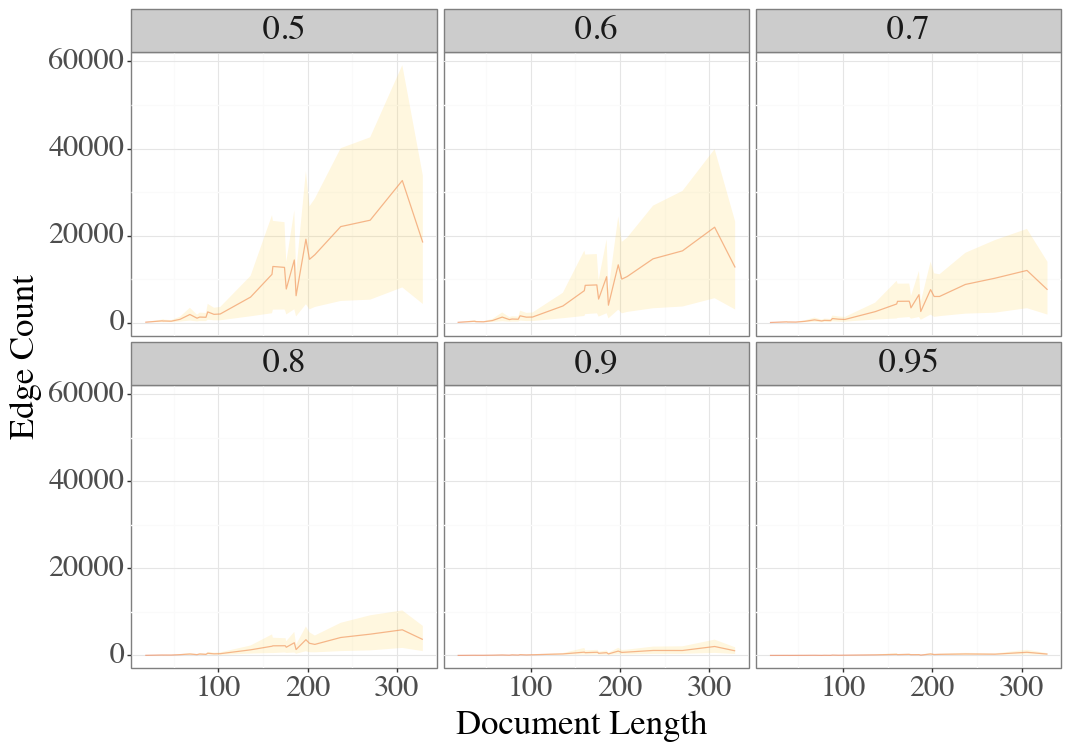

<ggplot: (336117412)>

In [16]:
p9.ggplot(
    chefer_importance_summary_df,
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_edge_count'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_edge_count', ymax = 'max_edge_count'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Edge Count') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

# Edge-to-Node Ratio

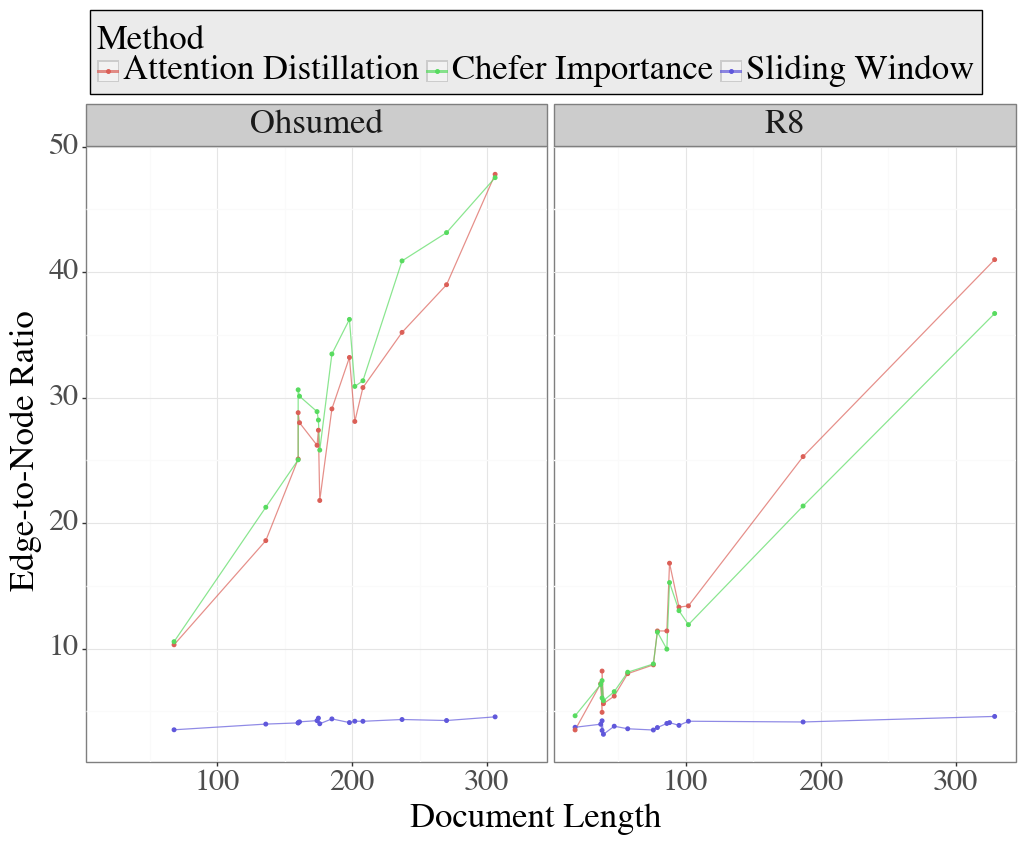

<ggplot: (336307612)>

In [17]:
p9.ggplot(
    df[df['param'].isin(['w=3','t=0.9','nt=0.7_et=0.8'])],
    p9.aes(x = 'document_length', y = 'edge_node_ratio', color = 'method')
  ) + \
    p9.geom_line(alpha = 0.7) + \
    p9.geom_point(size = 1) + \
    p9.xlab('Document Length') + \
    p9.ylab('Edge-to-Node Ratio') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

In [18]:
chefer_importance_memory_df = df[df['param'].isin([f'nt={x}_et={y}' for (x, y) in itertools.product([0.5, 0.6, 0.7, 0.8, 0.9, 0.95], repeat = 2)])]
chefer_importance_memory_df[['nt', 'et']] = chefer_importance_memory_df['param'].str.extract(r'nt=(.*)_et=(.*)').astype(float)
chefer_importance_summary_df = chefer_importance_memory_df.groupby(['nt', 'document_length']) \
  .agg(
    mean_edge_node_ratio = ('edge_node_ratio', 'mean'),
    min_edge_node_ratio = ('edge_node_ratio', 'min'),
    max_edge_node_ratio = ('edge_node_ratio', 'max')
  ) \
  .reset_index()

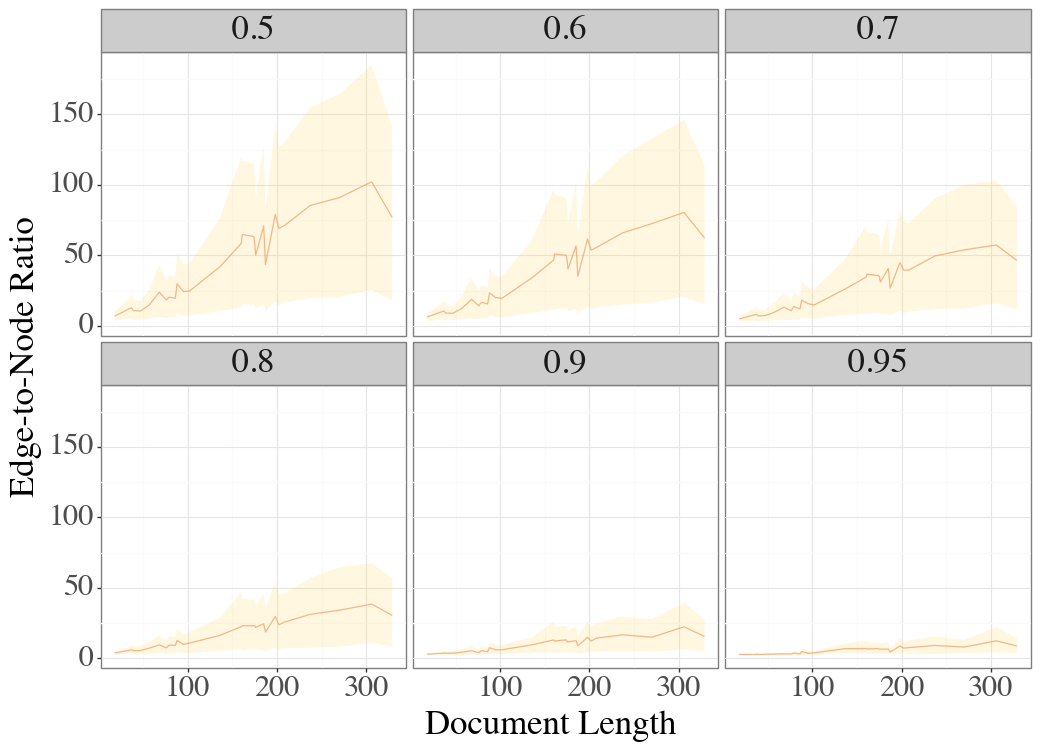

<ggplot: (336390874)>

In [19]:
p9.ggplot(
    chefer_importance_summary_df,
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_edge_node_ratio'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_edge_node_ratio', ymax = 'max_edge_node_ratio'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Edge-to-Node Ratio') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

# Graph Density vs Document Length

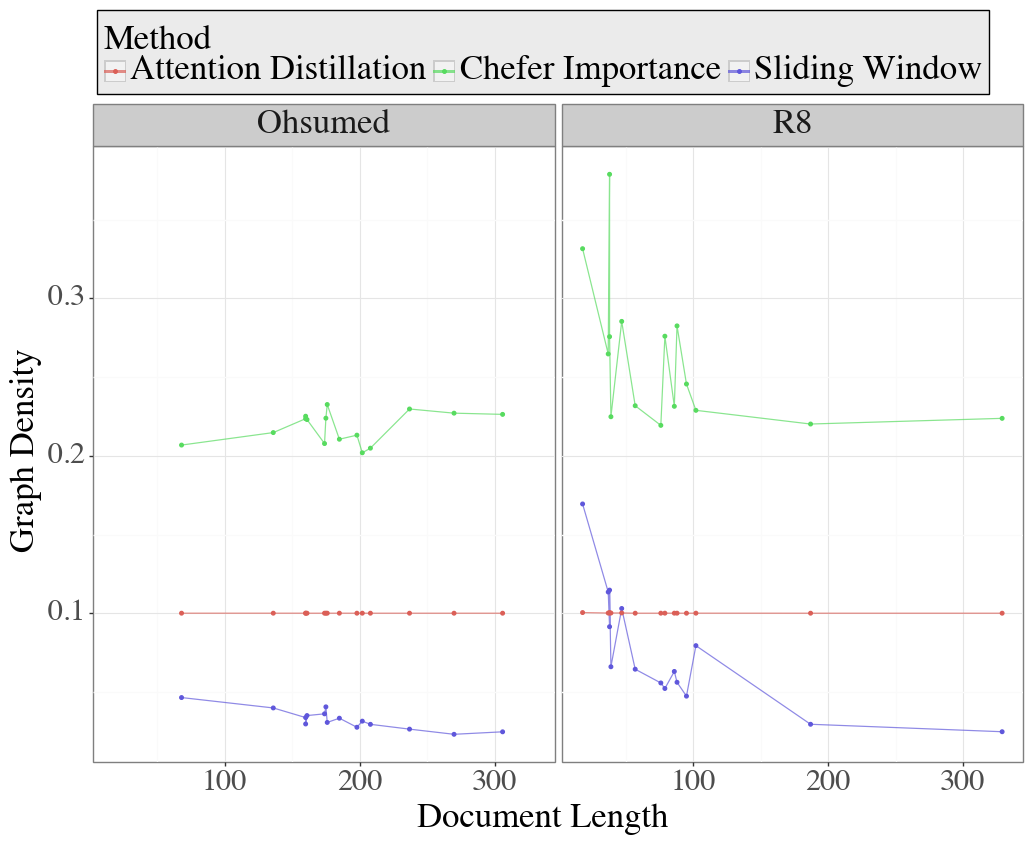

<ggplot: (336050192)>

In [20]:
p9.ggplot(
    df[df['param'].isin(['w=3','t=0.9','nt=0.7_et=0.8'])],
    p9.aes(x = 'document_length', y = 'graph_density', color = 'method')
  ) + \
    p9.geom_line(alpha = 0.7) + \
    p9.geom_point(size = 1) + \
    p9.xlab('Document Length') + \
    p9.ylab('Graph Density') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

In [21]:
chefer_importance_memory_df = df[df['param'].isin([f'nt={x}_et={y}' for (x, y) in itertools.product([0.5, 0.6, 0.7, 0.8, 0.9, 0.95], repeat = 2)])]
chefer_importance_memory_df[['nt', 'et']] = chefer_importance_memory_df['param'].str.extract(r'nt=(.*)_et=(.*)').astype(float)
chefer_importance_summary_df = chefer_importance_memory_df.groupby(['nt', 'document_length']) \
  .agg(
    mean_graph_density = ('graph_density', 'mean'),
    min_graph_density = ('graph_density', 'min'),
    max_graph_density = ('graph_density', 'max')
  ) \
  .reset_index()

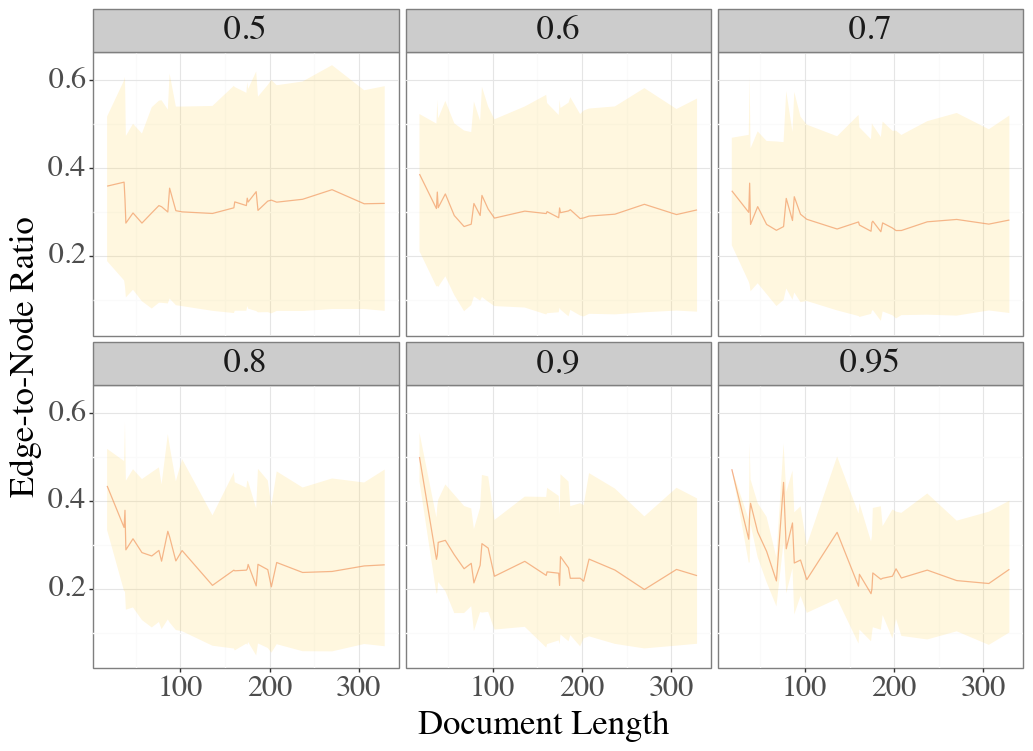

<ggplot: (335649456)>

In [22]:
p9.ggplot(
    chefer_importance_summary_df,
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_graph_density'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_graph_density', ymax = 'max_graph_density'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Edge-to-Node Ratio') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

# Scaling Exponent Analysis

In [23]:
def compute_scaling_exponents(df, variable_column, target_column):
  scaling_exponents = list()

  for (method, param), group in df.groupby(['method', 'param']):
    if len(group) < 2:
      continue

    X = np.log10(group[variable_column]).values.reshape(-1, 1)
    y = np.log10(group[target_column]).values

    model = sklearn.linear_model.LinearRegression().fit(X, y)
    slope = model.coef_[0]

    scaling_exponents.append({
      'method' : method,
      'param' : param,
      'metric' : target_column,
      'scaling_exponent' : slope
    })

  return pd.DataFrame(scaling_exponents)

In [24]:
memory_scaling_exponents = compute_scaling_exponents(df, 'document_length', 'total_mega_bytes')
edge_scaling_exponents = compute_scaling_exponents(df, 'document_length', 'edge_count')
scaling_exponents_df = pd.concat([memory_scaling_exponents, edge_scaling_exponents], ignore_index = True)
scaling_exponents_df.sort_values(['metric', 'method'])

,method,param,metric,scaling_exponent
46,Attention Distillation,t=0.6,edge_count,1.894375
47,Attention Distillation,t=0.7,edge_count,1.894271
48,Attention Distillation,t=0.8,edge_count,1.894247
49,Attention Distillation,t=0.9,edge_count,1.893483
50,Attention Distillation,t=0.95,edge_count,1.891910
...,...,...,...,...
41,Chefer Importance,nt=0.9_et=0.95,total_mega_bytes,0.988579
42,Sliding Window,w=2,total_mega_bytes,0.772011
43,Sliding Window,w=3,total_mega_bytes,0.772674
44,Sliding Window,w=4,total_mega_bytes,0.773536


In [25]:
scaling_exponents_df[['nt', 'et']] = scaling_exponents_df['param'].str.extract(r'nt=(.*?)_et=(.*)')
scaling_exponents_sliding_and_distillation = scaling_exponents_df[scaling_exponents_df['nt'].isna() & scaling_exponents_df['et'].isna()].rename(columns = {'scaling_exponent' : 'mean'}).assign(std = 0.0).drop(columns = ['nt', 'et'])
scaling_exponents_chefer_importance = scaling_exponents_df.dropna(subset = ['nt', 'et']) \
  .groupby(['metric', 'nt'])['scaling_exponent'] \
  .agg(['mean', 'std']) \
  .reset_index() \
  .rename(columns = {'nt' : 'param'}) \
  .assign(method = 'Chefer Importance')
scaling_exponents_chefer_importance['param'] = 'nt=' + scaling_exponents_chefer_importance['param']
aggregated_scaling_exponents_df = pd.concat([scaling_exponents_chefer_importance, scaling_exponents_sliding_and_distillation], ignore_index = True)
aggregated_scaling_exponents_df['label'] = aggregated_scaling_exponents_df['mean'].round(3).astype(str) + ' ± ' + aggregated_scaling_exponents_df['std'].round(3).astype(str)
aggregated_scaling_exponents_df['metric'] = aggregated_scaling_exponents_df['metric'].replace({
  'edge_count' : 'Edge Count',
  'total_mega_bytes' : 'Memory per Document (MB)',
})
aggregated_scaling_exponents_df['method'] = aggregated_scaling_exponents_df['method'].replace({
  'Chefer Importance' : 'CI',
  'Sliding Window' : 'SW',
  'Attention Distillation' : 'AD',
})

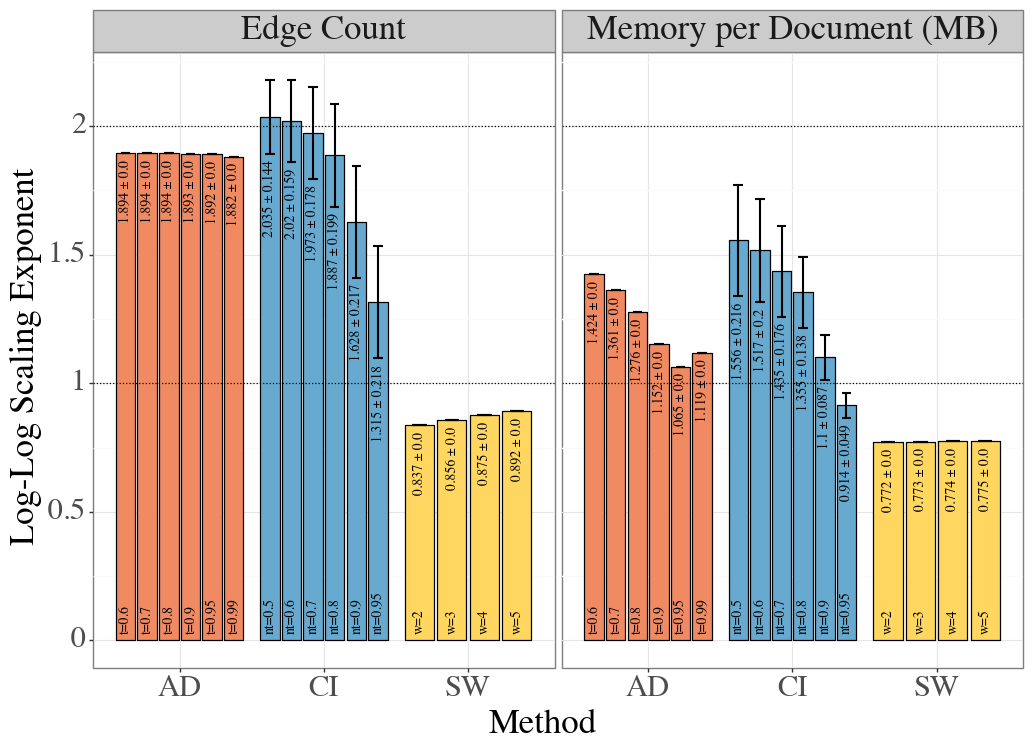

<ggplot: (335514829)>

In [26]:
p9.ggplot(
    aggregated_scaling_exponents_df,
    p9.aes(x = 'method', y = 'mean', group = 'param', fill = 'method')
  ) + \
    p9.geom_bar(stat = 'identity', position = p9.position_dodge2(), colour = '#000000') + \
    p9.geom_errorbar(p9.aes(ymin = 'mean - std', ymax = 'mean + std'), position = p9.position_dodge(width = .9), width = .4, size = .85) + \
    p9.geom_text(p9.aes(y = 'mean - std - 0.025', label = 'label'), position = p9.position_dodge2(width = .9), size = 10, angle = 90, va = 'top') + \
    p9.geom_text(p9.aes(y = '0.025', label = 'param'), position = p9.position_dodge2(width = .9), size = 10, angle = 90, va = 'bottom') + \
    p9.geom_hline(yintercept = 1.0, linetype = 'dotted') + \
    p9.geom_hline(yintercept = 2.0, linetype = 'dotted') + \
    p9.ylab('Log-Log Scaling Exponent') + \
    p9.xlab('Method') + \
    p9.facet_wrap(facets = '~ metric', ncol = 2) + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.theme(
      legend_position = 'none',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (12, 8),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )